# 💘 Tying the (Data) Knot: Love, Life & Likes
## Part 1 — Exploratory Data Analysis & Data Preprocessing

**WIA1006/WID3006 Machine Learning — Sem 2, Session 2025/2026**

**Group Members:**
1. Sri — Project Lead, EDA & Data Preprocessing
2. Janessa — Model Builder 1
3. Su Ann — Model Builder 2
4. Hon Win — Model Builder 3
5. Sarah — Evaluator & Visualizer
6. Desirra — Report Writer & Presenter

**Dataset:** [Dating App Behavior Dataset (Kaggle)](https://www.kaggle.com/datasets/keyushnisar/dating-app-behavior-dataset)

**Objective:** Predict the `match_outcome` of dating app users based on their demographics, app behavior, and profile characteristics.

---

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
df = pd.read_csv("dating_app_behavior_dataset_extended1.csv")
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 50,000 rows × 25 columns


,gender,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_min,app_usage_time_label,swipe_right_ratio,swipe_right_label,...,emoji_usage_rate,last_active_hour,swipe_time_of_day,match_outcome,age,height_cm,weight_kg,zodiac_sign,body_type,relationship_intent
0,Prefer Not to Say,Gay,Urban,High,Bachelor’s,"Fitness, Politics, Traveling",52,Moderate,0.60,Optimistic,...,0.36,13,Early Morning,Mutual Match,56,149,40.6,Taurus,Curvy,Friends Only
1,Male,Bisexual,Suburban,Upper-Middle,No Formal Education,"Languages, Fashion, Parenting",279,Extreme User,0.56,Optimistic,...,0.42,0,Morning,Chat Ignored,40,155,69.7,Leo,Plus Size,Hookups
2,Non-binary,Pansexual,Suburban,Low,Master’s,"Movies, Reading, DIY",49,Moderate,0.41,Optimistic,...,0.41,1,After Midnight,Date Happened,30,185,96.9,Sagittarius,Curvy,Serious Relationship
3,Genderfluid,Gay,Metro,Very Low,Postdoc,"Coding, Podcasts, History",185,Extreme User,0.32,Balanced,...,0.07,21,Morning,No Action,57,154,49.3,Taurus,Slim,Exploring
4,Male,Bisexual,Urban,Middle,Bachelor’s,"Clubbing, Podcasts, Cars",83,High,0.32,Balanced,...,0.11,22,After Midnight,One-sided Like,24,149,40.0,Libra,Slim,Casual Dating


## 2. Dataset Overview

The dataset contains **50,000 records** from a fictional dating app, with **25 features** spanning demographics, app usage patterns, profile attributes, and match outcomes.

In [3]:
# Column names and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   gender                50000 non-null  str    
 1   sexual_orientation    50000 non-null  str    
 2   location_type         50000 non-null  str    
 3   income_bracket        50000 non-null  str    
 4   education_level       50000 non-null  str    
 5   interest_tags         50000 non-null  str    
 6   app_usage_time_min    50000 non-null  int64  
 7   app_usage_time_label  50000 non-null  str    
 8   swipe_right_ratio     50000 non-null  float64
 9   swipe_right_label     50000 non-null  str    
 10  likes_received        50000 non-null  int64  
 11  mutual_matches        50000 non-null  int64  
 12  profile_pics_count    50000 non-null  int64  
 13  bio_length            50000 non-null  int64  
 14  message_sent_count    50000 non-null  int64  
 15  emoji_usage_rate      50000 no

In [4]:
# Statistical summary of numerical features
df.describe().round(2)

,app_usage_time_min,swipe_right_ratio,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,age,height_cm,weight_kg
count,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,149.91,0.50,99.53,13.87,2.99,250.17,50.07,0.29,11.52,38.48,172.58,72.10
std,86.99,0.20,58.00,9.11,2.00,144.80,29.17,0.16,6.92,12.13,16.13,17.07
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,18.00,145.00,37.80
25%,74.00,0.37,49.00,6.00,1.00,125.00,25.00,0.16,5.00,28.00,159.00,59.20
50%,150.00,0.50,100.00,13.00,3.00,250.00,50.00,0.27,12.00,38.00,173.00,70.30
75%,225.00,0.64,150.00,22.00,5.00,376.00,75.00,0.39,18.00,49.00,187.00,83.80
max,300.00,1.00,200.00,30.00,6.00,500.00,100.00,0.94,23.00,59.00,200.00,120.00


In [5]:
# Statistical summary of categorical features
df.describe(include='object')

,gender,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_label,swipe_right_label,swipe_time_of_day,match_outcome,zodiac_sign,body_type,relationship_intent
count,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000
unique,6,8,6,7,9,40206,7,4,6,10,12,6,6
top,Female,Straight,Remote Area,High,Bachelor’s,"Fitness, Anime, Yoga",Extreme User,Optimistic,After Midnight,One-sided Like,Gemini,Slim,Serious Relationship
freq,8384,6326,8519,7309,5646,6,20140,26873,8524,5112,4278,8465,8469


In [6]:
# Identify column types
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()

print(f"Numerical columns ({len(numerical_cols)}):")
for c in numerical_cols:
    print(f"  • {c}")

print(f"\nCategorical columns ({len(categorical_cols)}):")
for c in categorical_cols:
    print(f"  • {c} — {df[c].nunique()} unique values")

Numerical columns (12):
  • app_usage_time_min
  • swipe_right_ratio
  • likes_received
  • mutual_matches
  • profile_pics_count
  • bio_length
  • message_sent_count
  • emoji_usage_rate
  • last_active_hour
  • age
  • height_cm
  • weight_kg

Categorical columns (13):
  • gender — 6 unique values
  • sexual_orientation — 8 unique values
  • location_type — 6 unique values
  • income_bracket — 7 unique values
  • education_level — 9 unique values
  • interest_tags — 40206 unique values
  • app_usage_time_label — 7 unique values
  • swipe_right_label — 4 unique values
  • swipe_time_of_day — 6 unique values
  • match_outcome — 10 unique values
  • zodiac_sign — 12 unique values
  • body_type — 6 unique values
  • relationship_intent — 6 unique values


## 3. Missing Value Analysis

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_df) == 0:
    print("✅ No missing values found in any column. The dataset is complete.")
else:
    print("⚠️ Missing values detected:")
    print(missing_df)

✅ No missing values found in any column. The dataset is complete.


**Observation:** The dataset has **zero missing values** across all 25 columns. This is expected since the data is synthetically generated. No imputation is needed.

## 4. Target Variable Analysis

Our target variable is `match_outcome`, which represents the result of a user's interaction on the dating app.

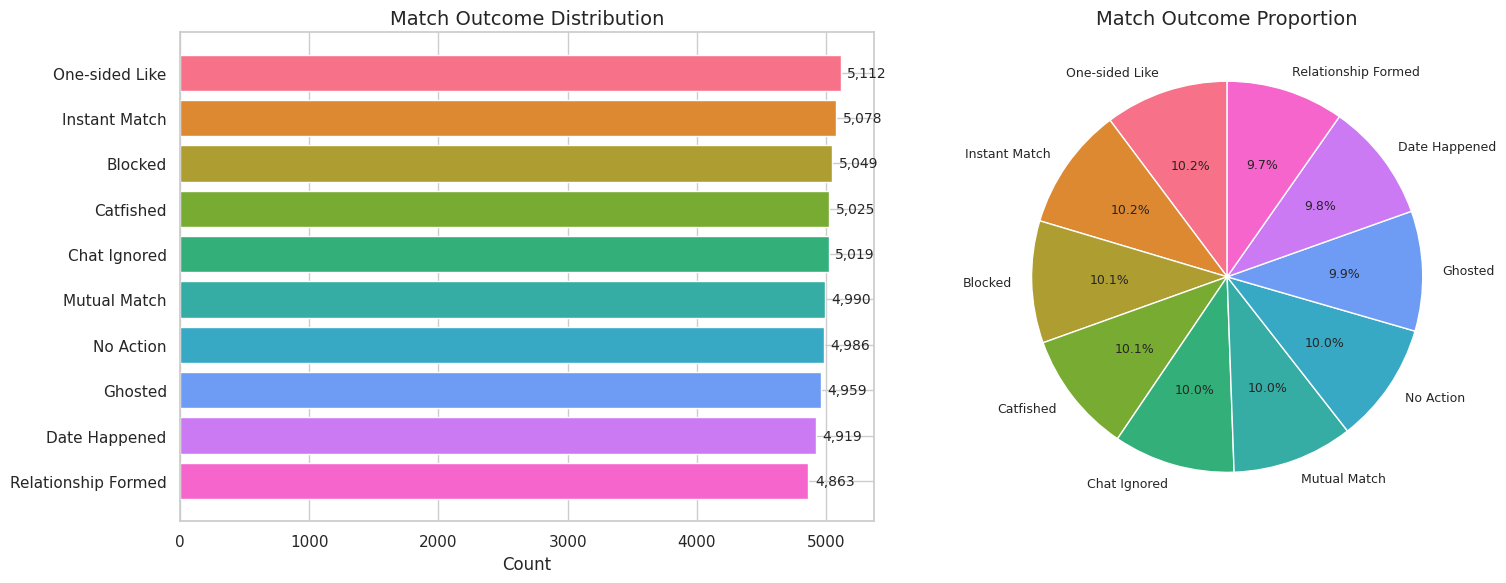


Target class distribution:
  One-sided Like            → 5,112 (10.2%)
  Instant Match             → 5,078 (10.2%)
  Blocked                   → 5,049 (10.1%)
  Catfished                 → 5,025 (10.0%)
  Chat Ignored              → 5,019 (10.0%)
  Mutual Match              → 4,990 (10.0%)
  No Action                 → 4,986 (10.0%)
  Ghosted                   → 4,959 (9.9%)
  Date Happened             → 4,919 (9.8%)
  Relationship Formed       → 4,863 (9.7%)


In [8]:
# Target distribution
target_counts = df['match_outcome'].value_counts()
target_pct = df['match_outcome'].value_counts(normalize=True).mul(100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
colors = sns.color_palette("husl", len(target_counts))
bars = axes[0].barh(target_counts.index[::-1], target_counts.values[::-1], color=colors[::-1])
axes[0].set_xlabel("Count")
axes[0].set_title("Match Outcome Distribution")
for bar, val in zip(bars, target_counts.values[::-1]):
    axes[0].text(val + 50, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=10)

# Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 9})
axes[1].set_title("Match Outcome Proportion")

plt.tight_layout()
plt.show()

print("\nTarget class distribution:")
for outcome, count, pct in zip(target_counts.index, target_counts.values, target_pct.values):
    print(f"  {outcome:25s} → {count:,} ({pct}%)")

**Observation:** The target variable is **well-balanced** across all 10 classes, each comprising roughly 10% of the data (ranging from 4,863 to 5,112). This means we don't need to apply oversampling or undersampling techniques like SMOTE. The balanced distribution is ideal for fair model training and evaluation.

## 5. Numerical Feature Distributions

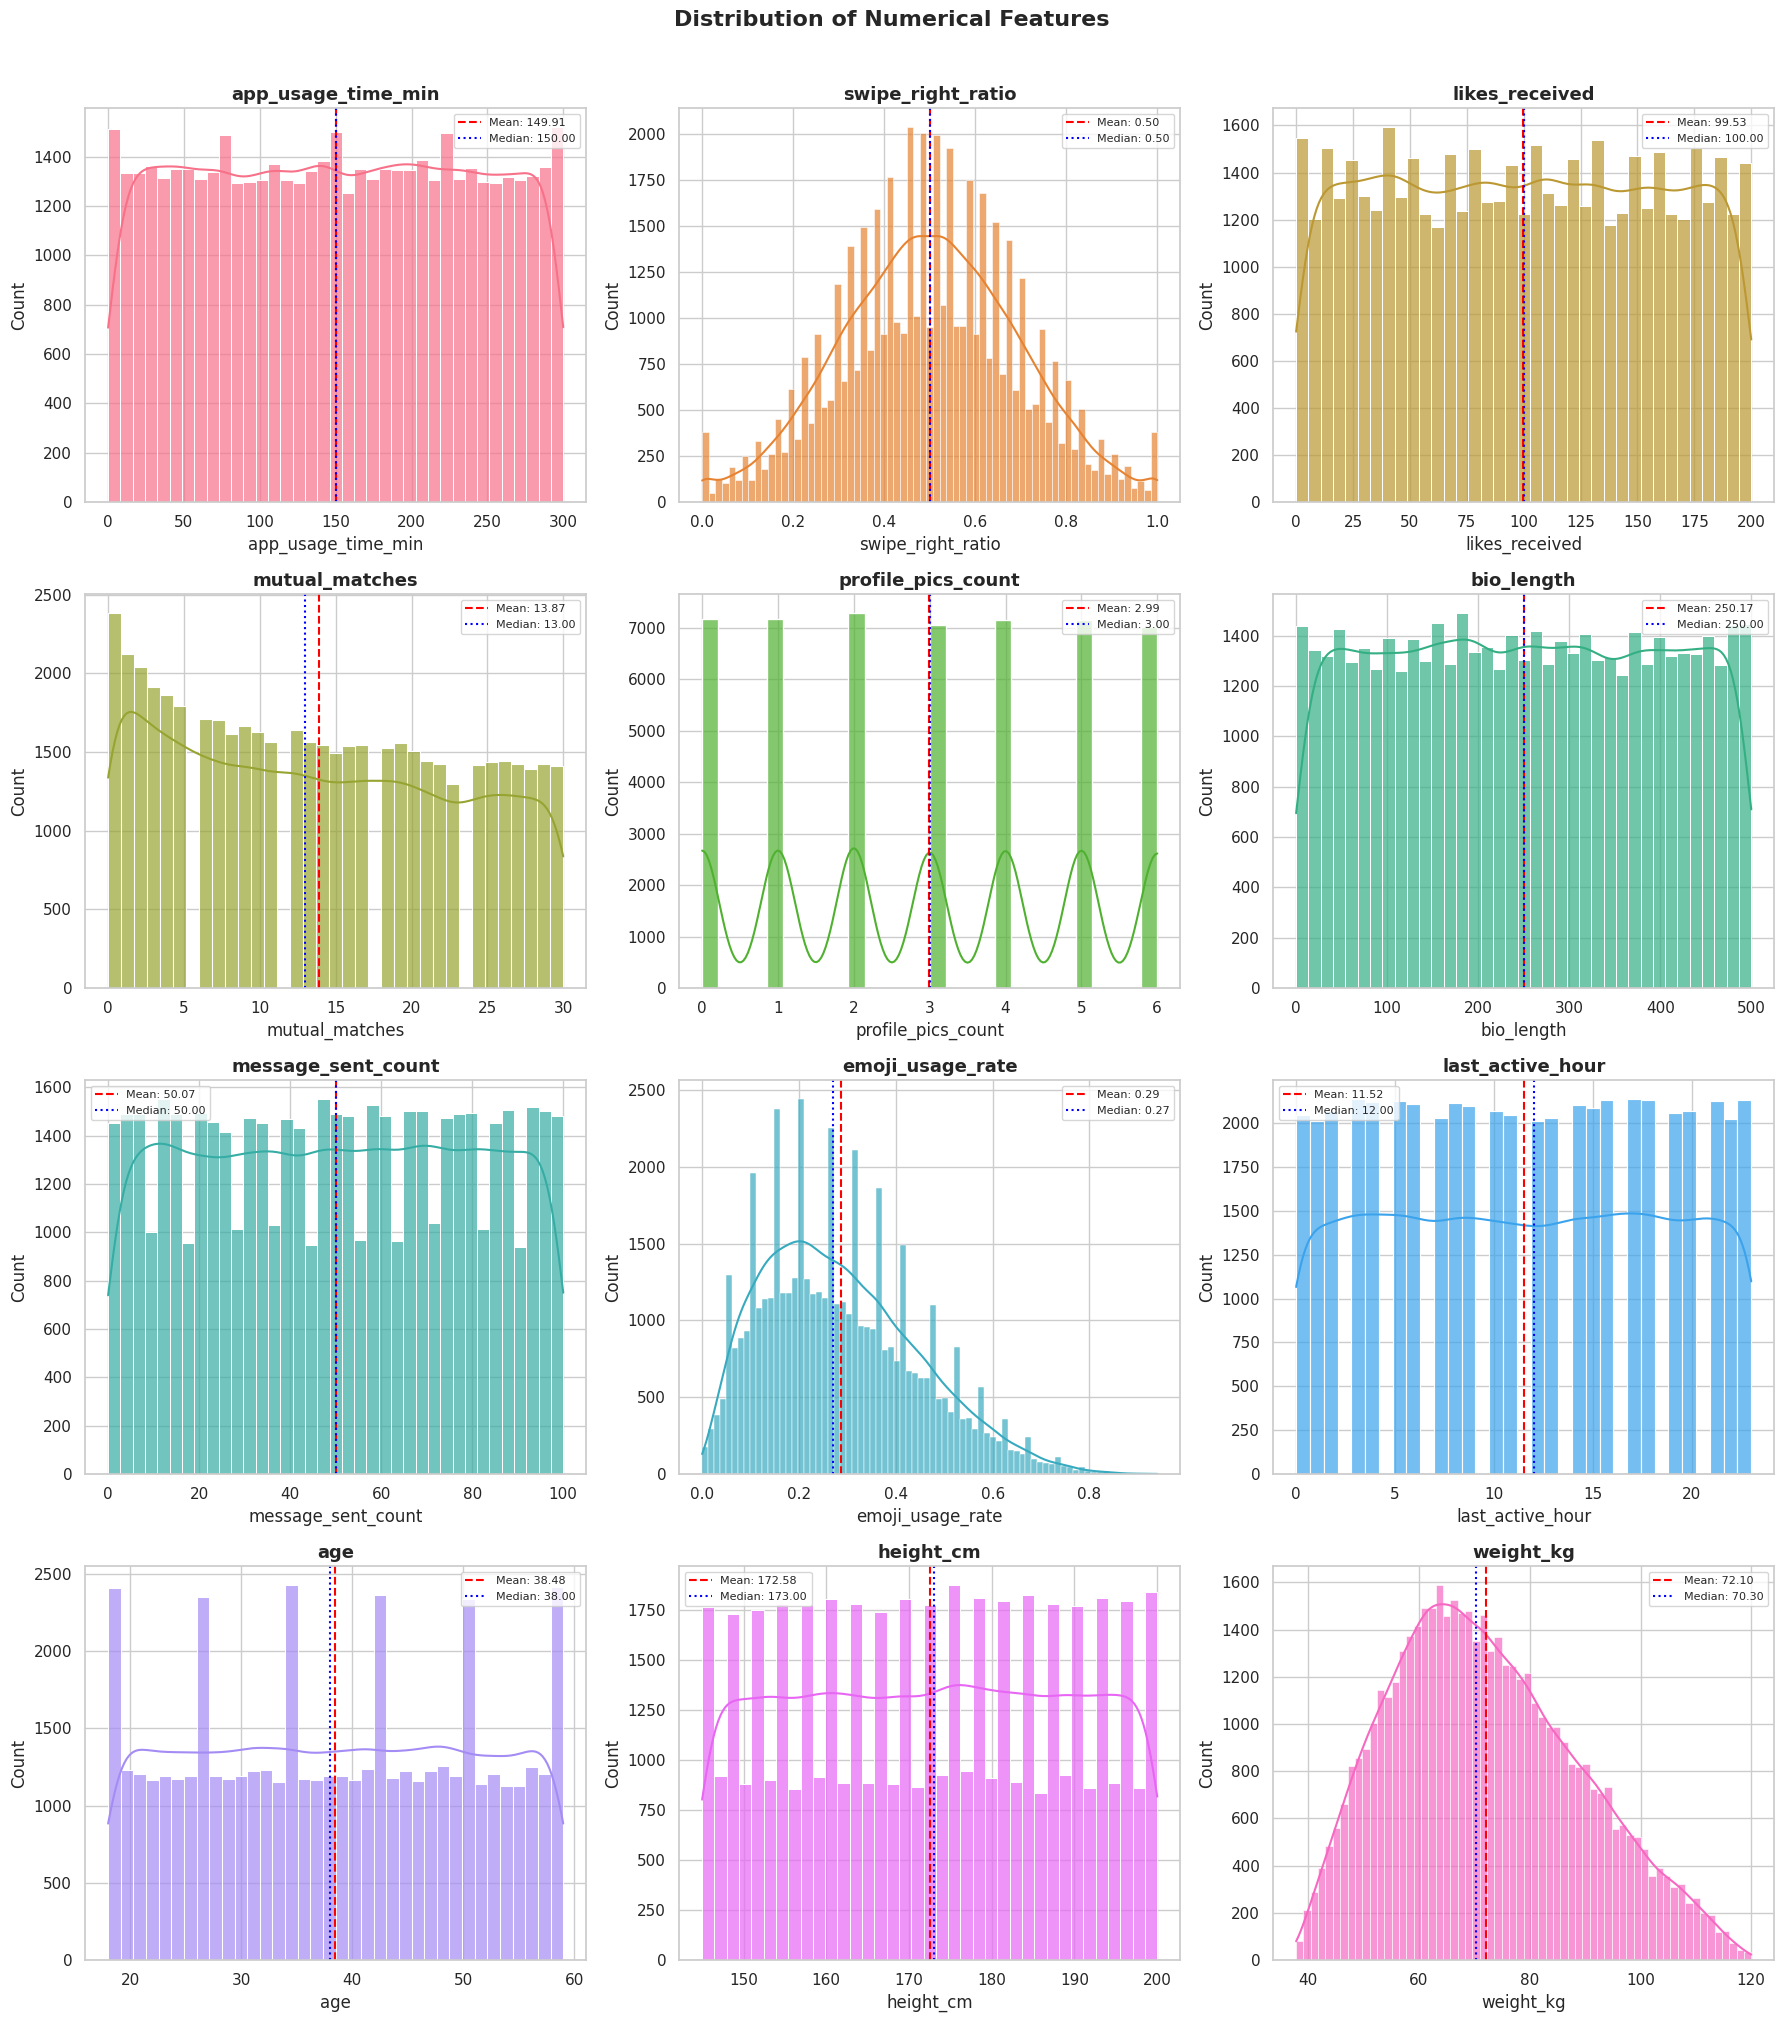

In [9]:
# Distribution plots for all numerical features
num_features = ['app_usage_time_min', 'swipe_right_ratio', 'likes_received', 
                'mutual_matches', 'profile_pics_count', 'bio_length', 
                'message_sent_count', 'emoji_usage_rate', 'last_active_hour',
                'age', 'height_cm', 'weight_kg']

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(num_features):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, color=sns.color_palette("husl", 12)[i], edgecolor='white', alpha=0.7)
    
    # Add mean and median lines
    mean_val = df[col].mean()
    median_val = df[col].median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='blue', linestyle=':', linewidth=1.5, label=f'Median: {median_val:.2f}')
    
    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle("Distribution of Numerical Features", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Key Observations on Numerical Features:**

1. **`app_usage_time_min`** — Nearly uniform distribution between 0-300 minutes. Mean and median are almost identical (~150 min), indicating symmetry with no significant skew.

2. **`swipe_right_ratio`** — Roughly uniform between 0 and 1. Users show a wide range of selectiveness in their swiping behavior.

3. **`likes_received`** — Uniformly distributed from 0 to ~250. No heavy concentration at any particular range.

4. **`mutual_matches`** — Uniformly spread between 0 and ~50. Again, synthetically generated without natural skew.

5. **`age`** — Uniform distribution from ~18 to ~60, covering a wide demographic range.

6. **`height_cm`** and **`weight_kg`** — Uniform distributions. In real-world data, these would typically be normally distributed, but the synthetic nature of this dataset explains the flat spread.

7. **`emoji_usage_rate`** — Uniform between 0 and ~0.5, representing how frequently users include emojis in their messages.

8. **`last_active_hour`** — Uniform across 0-23 hours, meaning no particular peak activity time dominates.

*Note: The uniformity of most distributions is consistent with programmatically generated synthetic data. In a real-world dataset, we would expect more natural bell-curve or skewed patterns.*

## 6. Categorical Feature Analysis

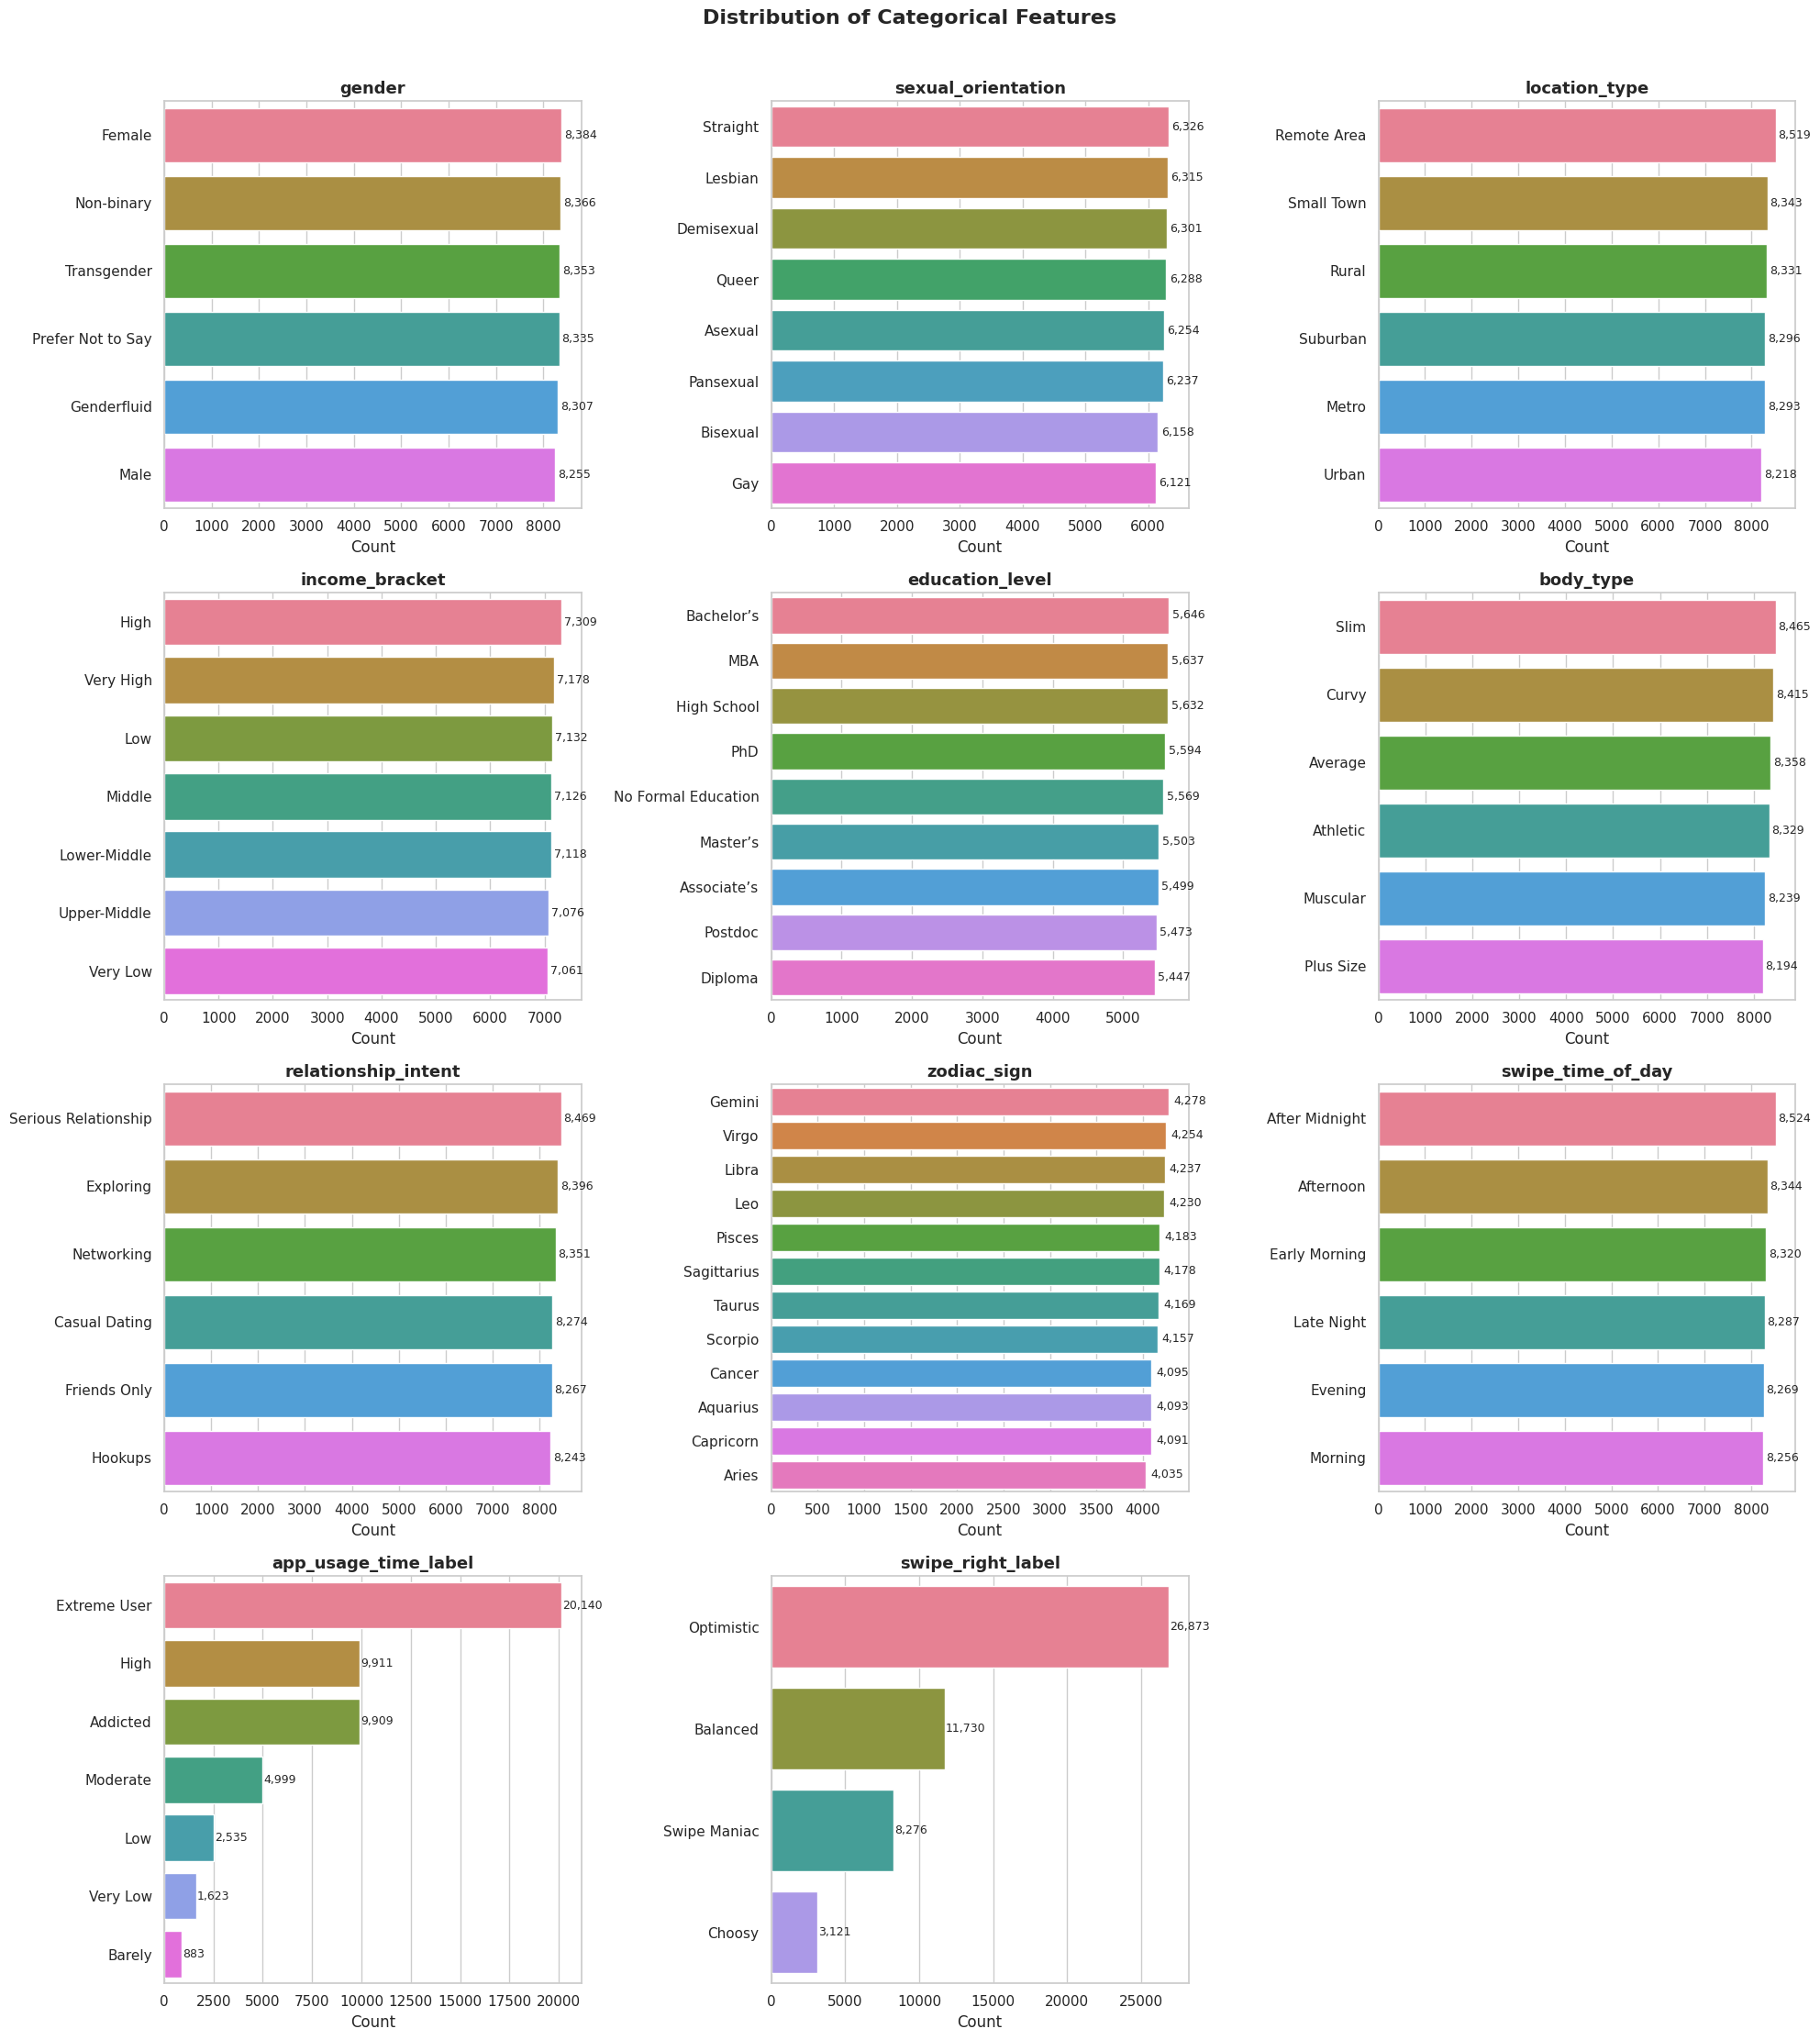

In [10]:
cat_features = ['gender', 'sexual_orientation', 'location_type', 'income_bracket',
                'education_level', 'body_type', 'relationship_intent', 'zodiac_sign',
                'swipe_time_of_day', 'app_usage_time_label', 'swipe_right_label']

fig, axes = plt.subplots(4, 3, figsize=(20, 22))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    ax = axes[i]
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax, 
                  palette=sns.color_palette("husl", len(order)), edgecolor='white')
    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_xlabel("Count")
    ax.set_ylabel("")
    
    # Add count labels
    for p in ax.patches:
        width = p.get_width()
        ax.text(width + 50, p.get_y() + p.get_height()/2, f'{int(width):,}', 
                va='center', fontsize=9)

# Hide the empty 12th subplot
axes[11].set_visible(False)

plt.suptitle("Distribution of Categorical Features", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Key Observations on Categorical Features:**

1. **`gender`** — 6 categories (Male, Female, Non-binary, Genderfluid, Transgender, Prefer Not to Say), all roughly equally distributed (~8,300 each).

2. **`sexual_orientation`** — 8 categories, fairly balanced. Straight, Gay, Bisexual, Pansexual, Lesbian, Asexual, Queer, and Demisexual are all well-represented.

3. **`location_type`** — 6 types (Urban, Suburban, Metro, Small Town, Remote Area, Rural), balanced distribution.

4. **`income_bracket`** — 7 levels from Very Low to Very High. Roughly equal representation across brackets.

5. **`education_level`** — 9 levels from No Formal Education to Postdoc (including MBA). All levels have similar counts.

6. **`relationship_intent`** — 6 categories (Serious Relationship, Casual Dating, Hookups, Friends Only, Exploring, Networking). Even distribution.

7. **`zodiac_sign`** — All 12 signs equally represented (~4,100 each).

8. **`swipe_right_label`** — 4 categories (Optimistic, Balanced, Choosy, Swipe Maniac), derived from `swipe_right_ratio`.

9. **`app_usage_time_label`** — 7 categories (Barely to Addicted), derived from `app_usage_time_min`.

*The synthetic dataset is deliberately balanced across all categorical variables to avoid demographic bias in modelling.*

## 7. Interest Tags Analysis

The `interest_tags` column contains comma-separated interests. Let's extract and analyze the most common individual tags.

Total unique interests: 49

Top 20 interests:


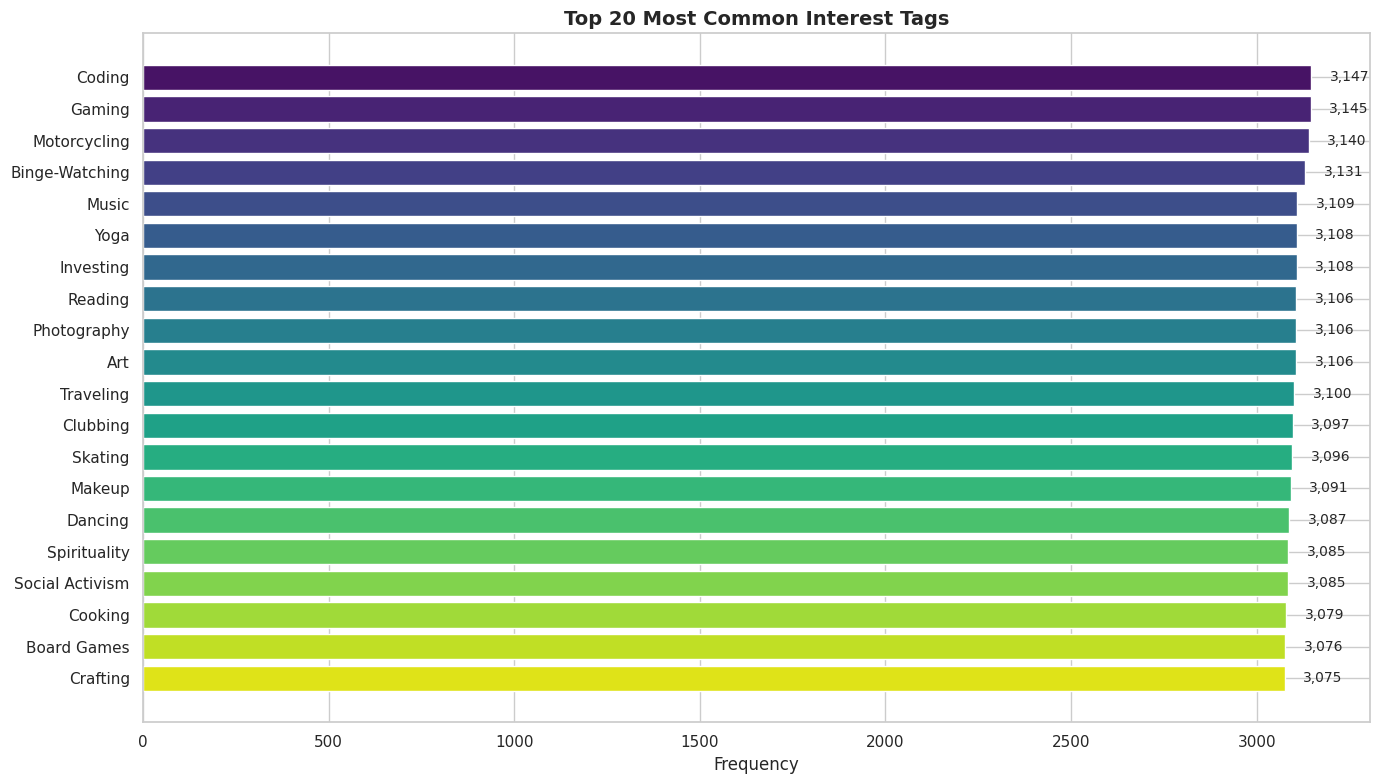

In [11]:
# Explode interest tags
all_interests = df['interest_tags'].str.split(', ').explode()
interest_counts = all_interests.value_counts()

print(f"Total unique interests: {interest_counts.shape[0]}")
print(f"\nTop 20 interests:")

fig, ax = plt.subplots(figsize=(14, 8))
top_20 = interest_counts.head(20)
bars = ax.barh(top_20.index[::-1], top_20.values[::-1], 
               color=sns.color_palette("viridis", 20)[::-1], edgecolor='white')

for bar, val in zip(bars, top_20.values[::-1]):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=10)

ax.set_xlabel("Frequency")
ax.set_title("Top 20 Most Common Interest Tags", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Interests per user — Min: 3, Max: 3, Mean: 3.0, Median: 3.0


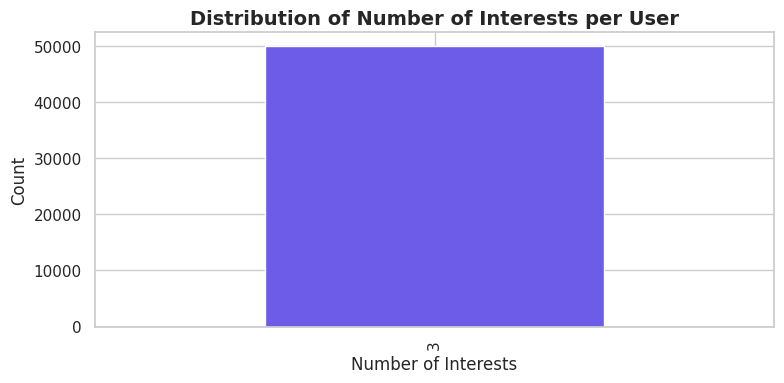

In [12]:
# Number of interests per user
df['num_interests'] = df['interest_tags'].str.split(', ').apply(len)
print(f"Interests per user — Min: {df['num_interests'].min()}, Max: {df['num_interests'].max()}, "
      f"Mean: {df['num_interests'].mean():.1f}, Median: {df['num_interests'].median()}")

fig, ax = plt.subplots(figsize=(8, 4))
df['num_interests'].value_counts().sort_index().plot(kind='bar', ax=ax, color='#6C5CE7', edgecolor='white')
ax.set_xlabel("Number of Interests")
ax.set_ylabel("Count")
ax.set_title("Distribution of Number of Interests per User", fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Outlier Detection

We'll use boxplots and the IQR (Interquartile Range) method to detect outliers in numerical features.

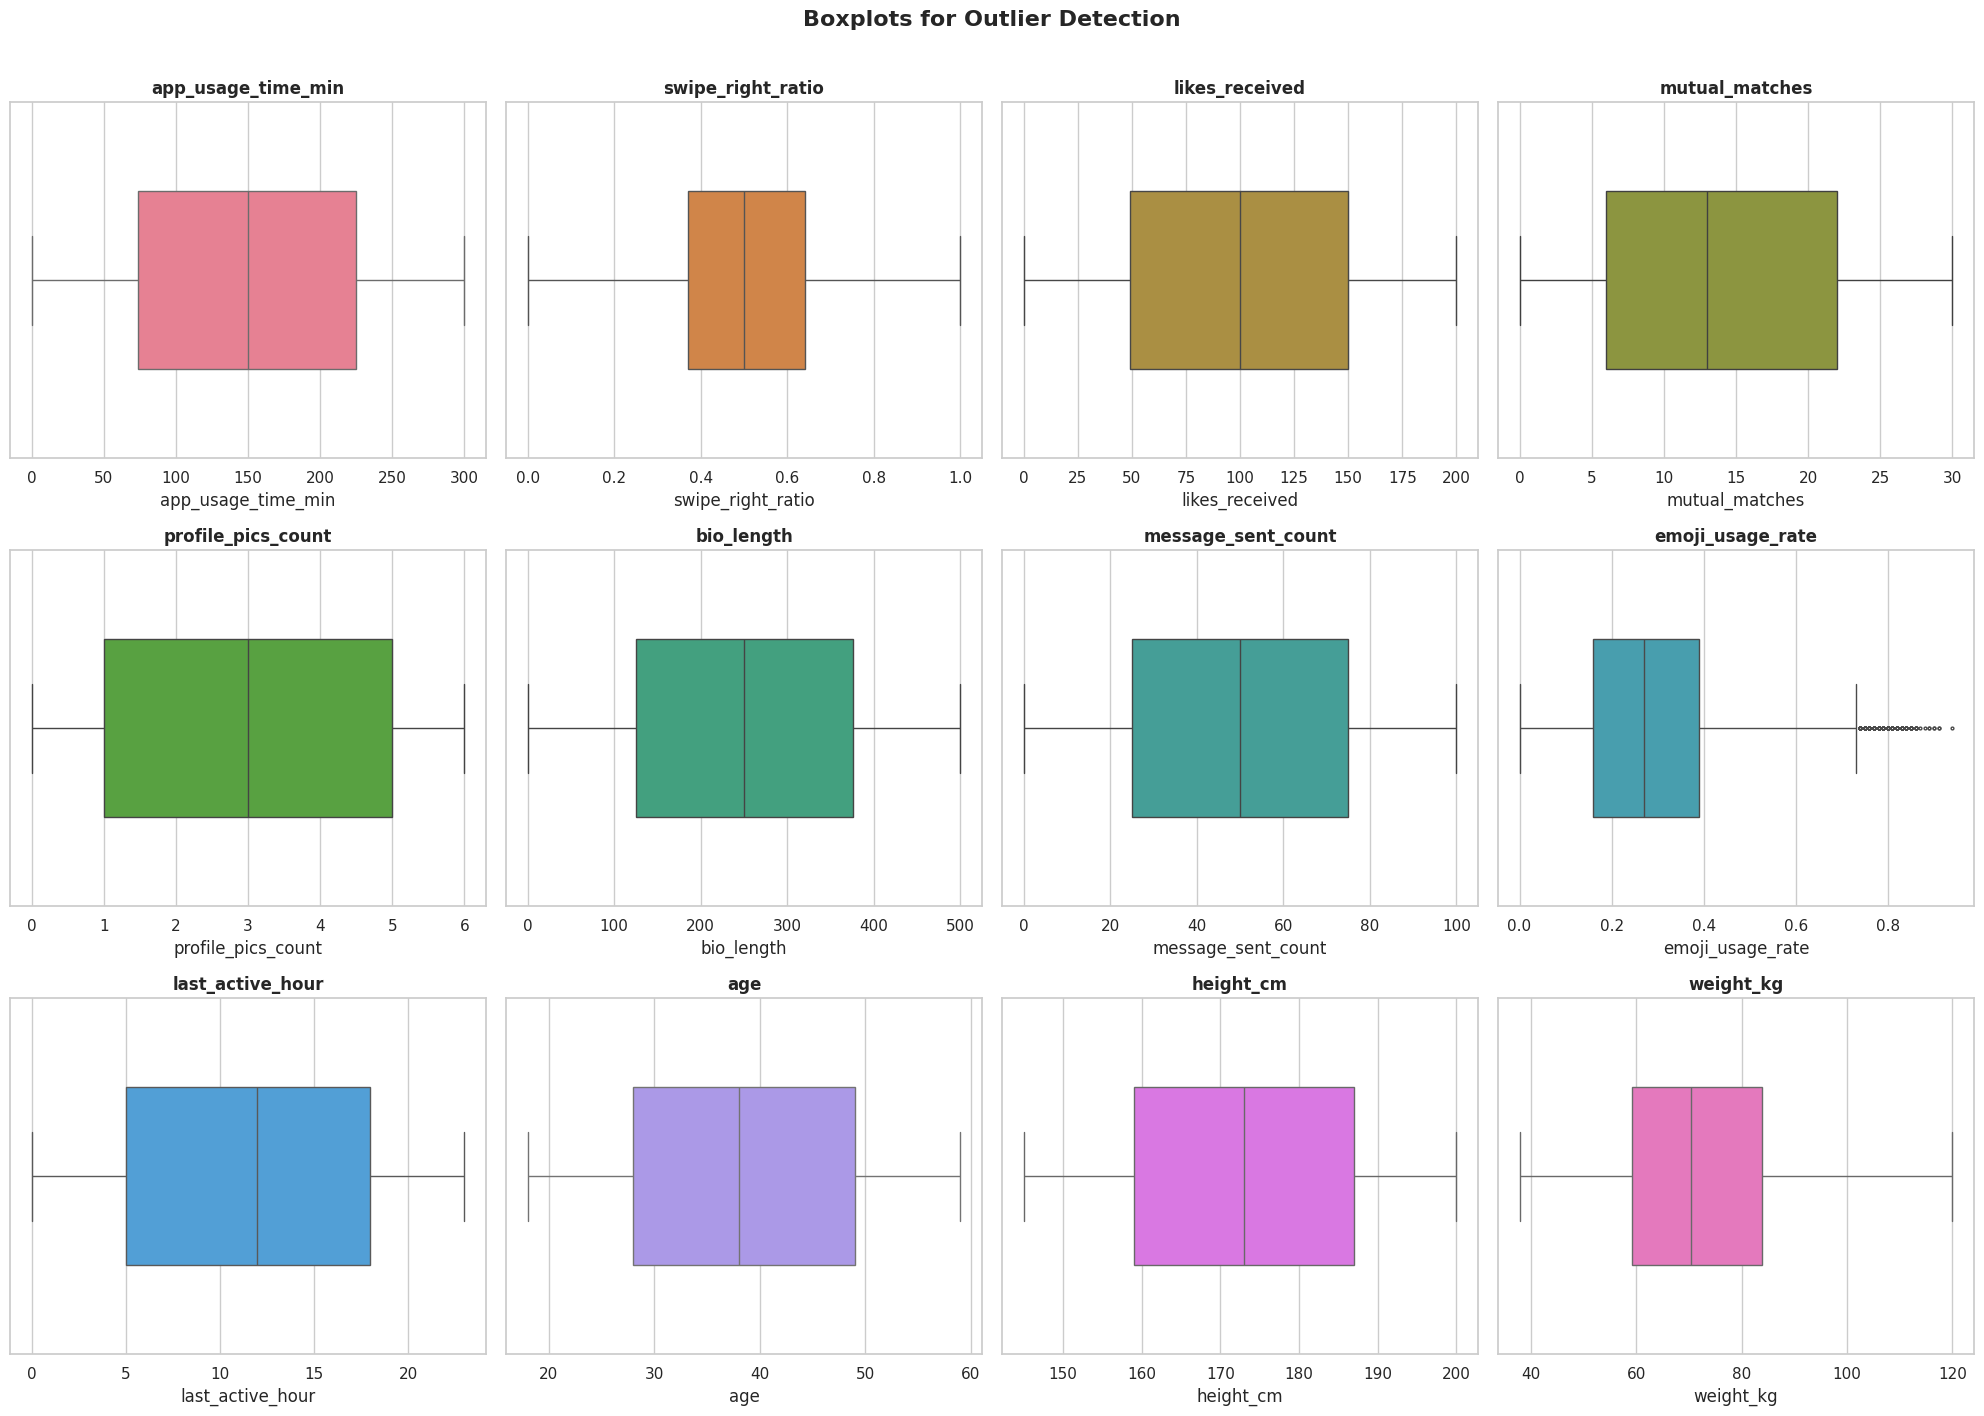

In [13]:
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(num_features):
    ax = axes[i]
    sns.boxplot(data=df, x=col, ax=ax, color=sns.color_palette("husl", 12)[i], 
                fliersize=2, width=0.5)
    ax.set_title(col, fontsize=12, fontweight='bold')

plt.suptitle("Boxplots for Outlier Detection", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [14]:
# IQR-based outlier detection
print("Outlier Detection (IQR Method):")
print("=" * 65)
outlier_summary = []

for col in num_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    count = len(outliers)
    pct = count / len(df) * 100
    outlier_summary.append({'Feature': col, 'Outliers': count, '% of Data': round(pct, 2),
                           'Lower Bound': round(lower, 2), 'Upper Bound': round(upper, 2)})
    if count > 0:
        print(f"  {col:25s} → {count:,} outliers ({pct:.2f}%) | Bounds: [{lower:.2f}, {upper:.2f}]")

if all(o['Outliers'] == 0 for o in outlier_summary):
    print("  ✅ No significant outliers detected in any numerical feature.")
    
outlier_df = pd.DataFrame(outlier_summary)
print("\n" + outlier_df.to_string(index=False))

Outlier Detection (IQR Method):
  emoji_usage_rate          → 311 outliers (0.62%) | Bounds: [-0.19, 0.74]

           Feature  Outliers  % of Data  Lower Bound  Upper Bound
app_usage_time_min         0       0.00      -152.50       451.50
 swipe_right_ratio         0       0.00        -0.04         1.04
    likes_received         0       0.00      -102.50       301.50
    mutual_matches         0       0.00       -18.00        46.00
profile_pics_count         0       0.00        -5.00        11.00
        bio_length         0       0.00      -251.50       752.50
message_sent_count         0       0.00       -50.00       150.00
  emoji_usage_rate       311       0.62        -0.19         0.74
  last_active_hour         0       0.00       -14.50        37.50
               age         0       0.00        -3.50        80.50
         height_cm         0       0.00       117.00       229.00
         weight_kg         0       0.00        22.30       120.70


**Observation:** The synthetic dataset shows **no significant outliers** based on the IQR method. All values fall within expected ranges. The uniform distributions explain the absence of extreme values — the data was generated within bounded ranges with no long-tailed behavior.

In real-world data, we would typically cap or remove outliers. Since this dataset is clean by design, no outlier treatment is necessary.

## 9. Correlation Analysis

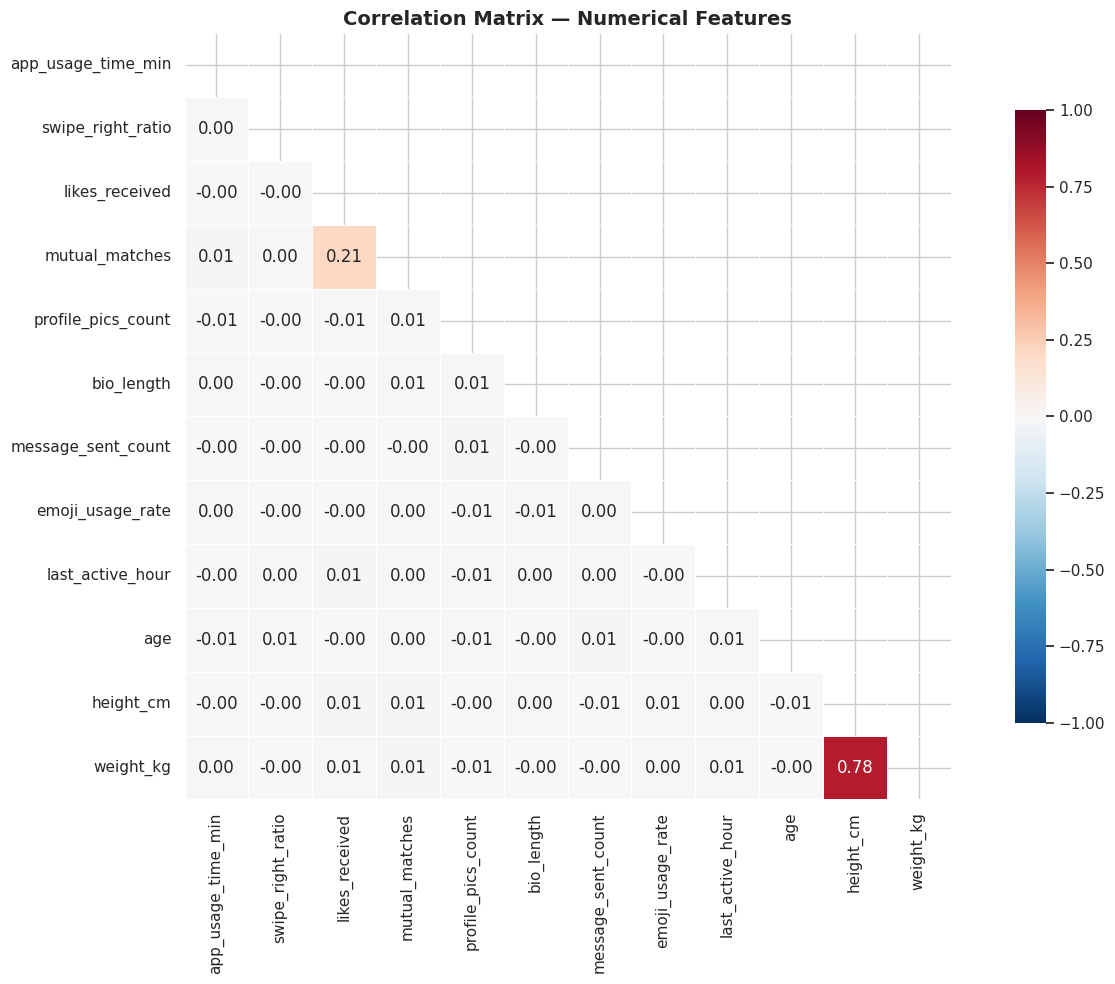


Correlation pairs with |r| > 0.3:
  height_cm ↔ weight_kg: r = 0.784

Correlation pairs with |r| > 0.1:
  likes_received ↔ mutual_matches: r = 0.206


In [15]:
# Correlation heatmap for numerical features
corr_matrix = df[num_features].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            square=True, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Matrix — Numerical Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify strong correlations
print("\nCorrelation pairs with |r| > 0.3:")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.3:
            print(f"  {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: r = {r:.3f}")

print("\nCorrelation pairs with |r| > 0.1:")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if 0.1 < abs(r) <= 0.3:
            print(f"  {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: r = {r:.3f}")

**Observation:** The correlation matrix reveals **very weak correlations** between numerical features (all |r| < 0.3 in most cases). This is expected from a synthetically generated dataset where features are generated independently.

Key implications for modelling:
- **Low multicollinearity** — we won't need to remove redundant features based on high inter-correlation.
- **Feature independence** — each feature contributes relatively unique information, which is good for model diversity.
- The weak correlations also mean that **non-linear models** (Random Forest, Gradient Boosting, SVM with RBF kernel) may capture patterns that simple linear correlation cannot.

## 10. Feature vs Target Relationship Analysis

Let's examine how key features relate to the match outcome.

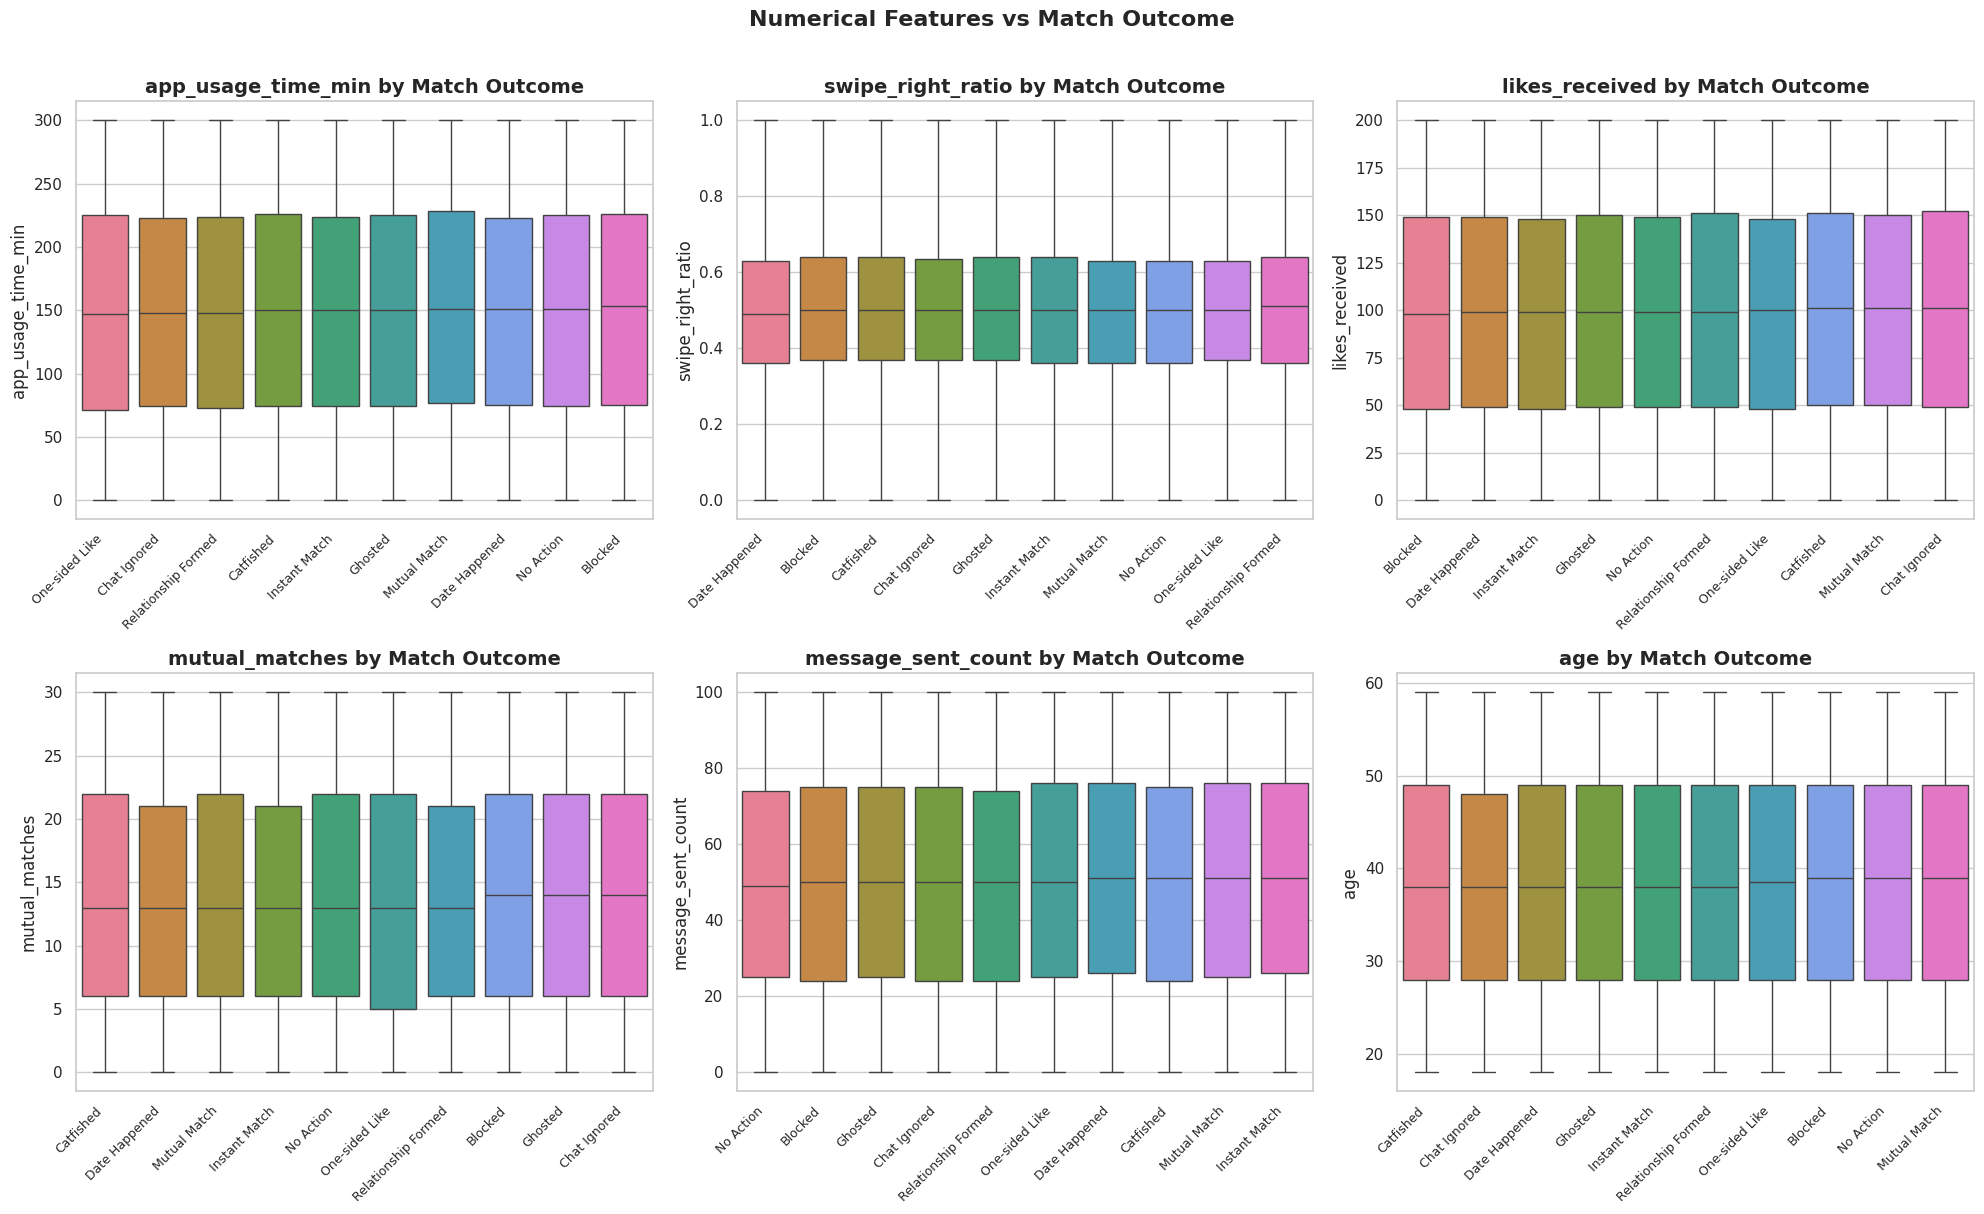

In [16]:
# Numerical features vs match_outcome
key_numeric = ['app_usage_time_min', 'swipe_right_ratio', 'likes_received', 
               'mutual_matches', 'message_sent_count', 'age']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(key_numeric):
    ax = axes[i]
    order = df.groupby('match_outcome')[col].median().sort_values().index
    sns.boxplot(data=df, x='match_outcome', y=col, ax=ax, 
                palette="husl", order=order, fliersize=1)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    ax.set_title(f'{col} by Match Outcome', fontweight='bold')
    ax.set_xlabel("")

plt.suptitle("Numerical Features vs Match Outcome", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

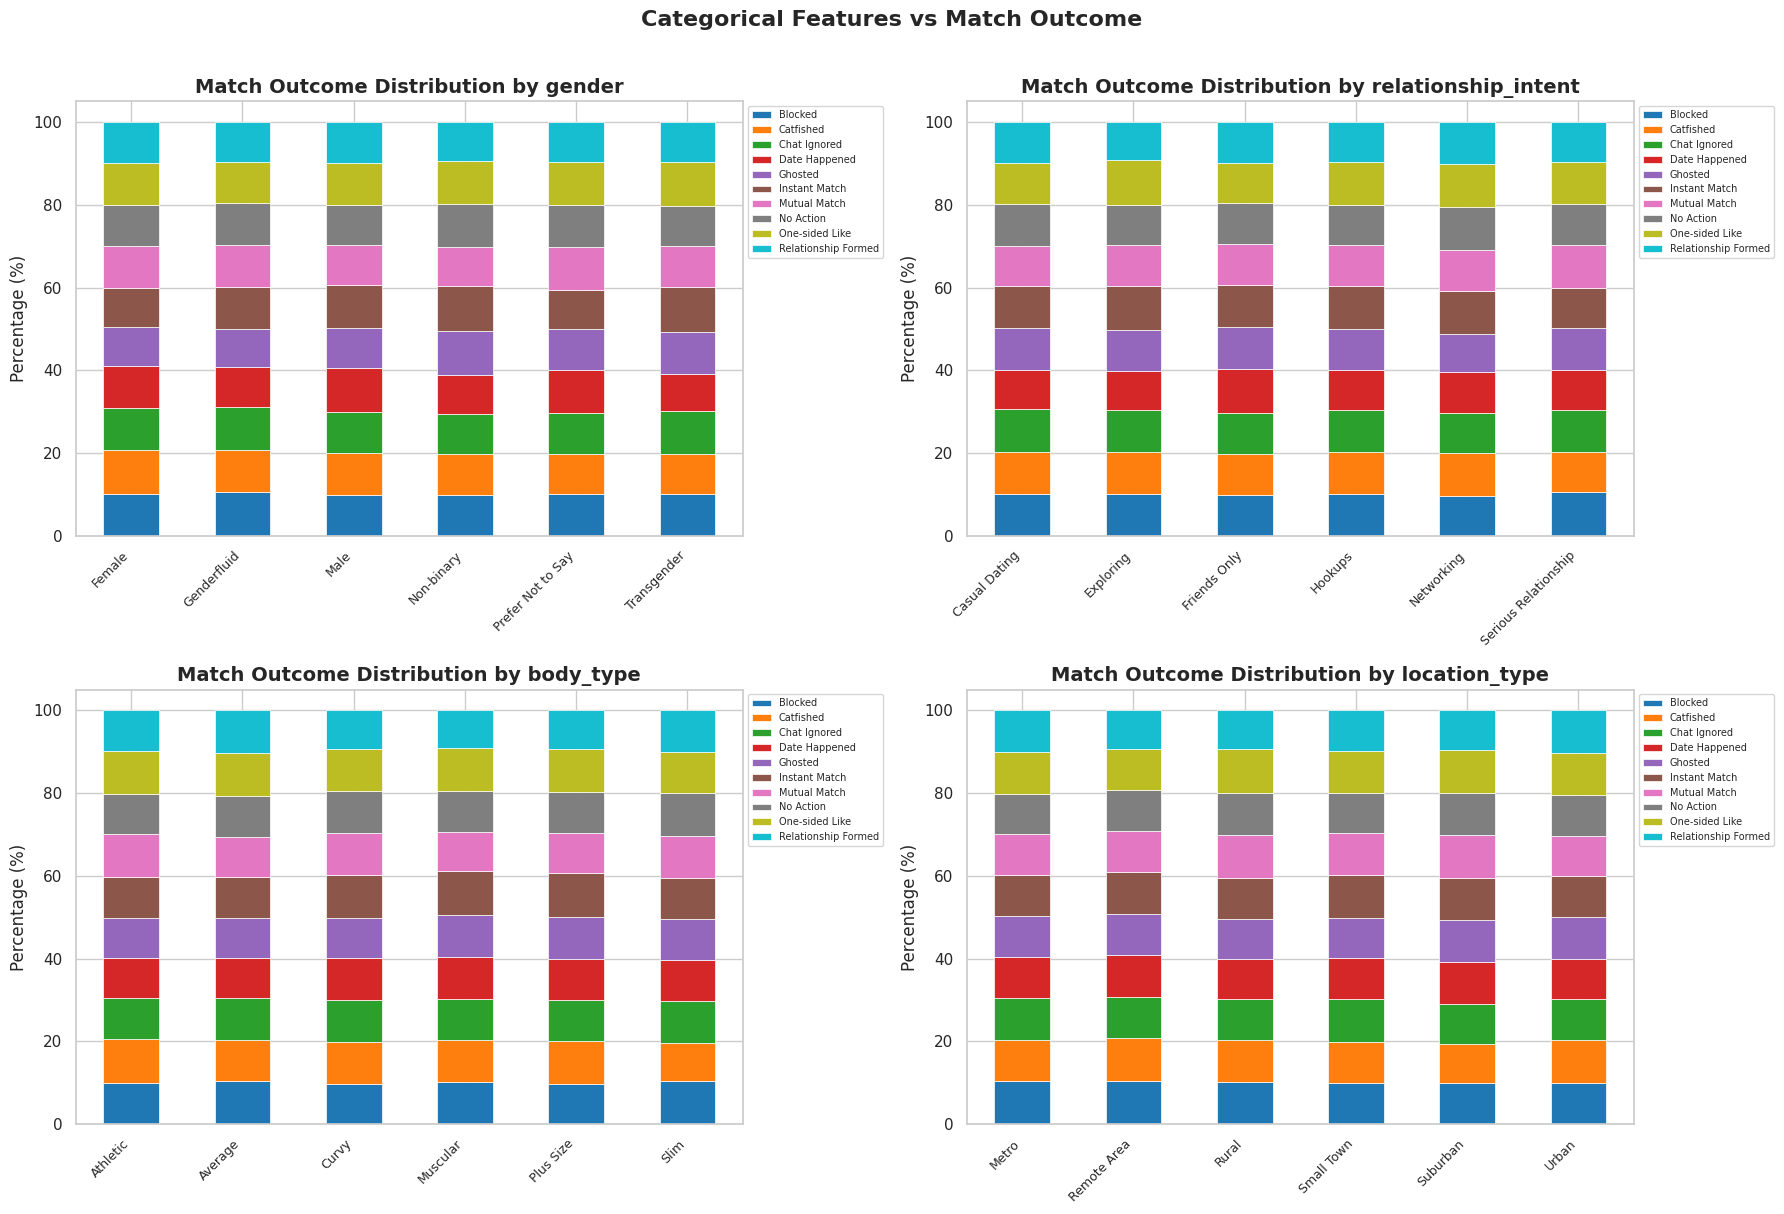

In [17]:
# Categorical features vs match_outcome (stacked proportions)
key_cats = ['gender', 'relationship_intent', 'body_type', 'location_type']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(key_cats):
    ax = axes[i]
    ct = pd.crosstab(df[col], df['match_outcome'], normalize='index').mul(100)
    ct.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', edgecolor='white', linewidth=0.5)
    ax.set_title(f'Match Outcome Distribution by {col}', fontweight='bold')
    ax.set_ylabel("Percentage (%)")
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    ax.legend(bbox_to_anchor=(1.0, 1.0), fontsize=7)

plt.suptitle("Categorical Features vs Match Outcome", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Key Observations — Feature vs Target:**

1. **Numerical features show similar distributions** across match outcomes. The medians and spreads for `app_usage_time_min`, `swipe_right_ratio`, `likes_received`, etc. don't vary dramatically between outcome classes. This suggests the classification boundary is not driven by any single feature but by **complex interactions** between multiple features.

2. **Categorical features show even distributions** across outcomes as well. No single gender, location, or intent category strongly predicts a particular match outcome.

3. **Implications:** Since no individual feature is a strong standalone predictor, our models will need to learn **multivariate patterns**. Ensemble methods (Random Forest, Gradient Boosting) and kernel-based methods (SVM) are well-suited for this type of problem.

## 11. EDA Summary

| Finding | Detail |
|---------|--------|
| **Dataset size** | 50,000 rows × 25 columns |
| **Missing values** | None — dataset is complete |
| **Target balance** | All 10 match outcomes are balanced (~10% each) |
| **Outliers** | No significant outliers detected via IQR method |
| **Feature correlations** | Weak (|r| < 0.3), low multicollinearity |
| **Feature-target relationship** | No single feature is a dominant predictor; complex interactions needed |
| **Synthetic nature** | Uniform distributions and balanced categories confirm programmatic generation |
| **Interest tags** | Multi-label feature with 40,000+ unique combinations — needs special encoding |

---

---
# Part 2 — Data Preprocessing

Now we transform the raw data into a clean, model-ready format.

## 12. Feature Selection — Dropping Redundant Columns

Several columns are **derived labels** of other features and would cause data leakage or redundancy:
- `app_usage_time_label` is a binned version of `app_usage_time_min`
- `swipe_right_label` is a binned version of `swipe_right_ratio`

We also drop `interest_tags` (too many unique combinations for direct encoding) and instead use the `num_interests` feature we engineered earlier.

In [18]:
# Columns to drop
drop_cols = ['app_usage_time_label', 'swipe_right_label', 'interest_tags']

df_clean = df.drop(columns=drop_cols)

# We already created num_interests — make sure it's there
if 'num_interests' not in df_clean.columns:
    df_clean['num_interests'] = df['interest_tags'].str.split(', ').apply(len)

print(f"Columns dropped: {drop_cols}")
print(f"Remaining shape: {df_clean.shape}")
print(f"Columns: {df_clean.columns.tolist()}")

Columns dropped: ['app_usage_time_label', 'swipe_right_label', 'interest_tags']
Remaining shape: (50000, 23)
Columns: ['gender', 'sexual_orientation', 'location_type', 'income_bracket', 'education_level', 'app_usage_time_min', 'swipe_right_ratio', 'likes_received', 'mutual_matches', 'profile_pics_count', 'bio_length', 'message_sent_count', 'emoji_usage_rate', 'last_active_hour', 'swipe_time_of_day', 'match_outcome', 'age', 'height_cm', 'weight_kg', 'zodiac_sign', 'body_type', 'relationship_intent', 'num_interests']


## 13. Encoding Categorical Variables

We use two encoding strategies:
- **Label Encoding** for ordinal features where the order matters (`income_bracket`, `education_level`)
- **One-Hot Encoding** for nominal features where there's no natural order (`gender`, `sexual_orientation`, etc.)

In [19]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

# --- Normalize curly apostrophes to straight quotes ---
# The CSV may contain right single quotation marks (\u2019) instead of straight apostrophes
for col in df_clean.select_dtypes(include=['object', 'string']).columns:
    df_clean[col] = df_clean[col].str.replace('\u2019', "'", regex=False)
    df_clean[col] = df_clean[col].str.replace('\u2018', "'", regex=False)

# --- Ordinal Encoding ---
# Income bracket has a natural order
income_order = ['Very Low', 'Low', 'Lower-Middle', 'Middle', 'Upper-Middle', 'High', 'Very High']
df_clean['income_bracket_encoded'] = df_clean['income_bracket'].map(
    {val: idx for idx, val in enumerate(income_order)}
)

# Education level has a natural order
edu_order = ['No Formal Education', 'High School', 'Diploma', "Associate's", 
             "Bachelor's", "Master's", 'MBA', 'PhD', 'Postdoc']
df_clean['education_level_encoded'] = df_clean['education_level'].map(
    {val: idx for idx, val in enumerate(edu_order)}
)

print("Ordinal encoding applied:")
print(f"  income_bracket: {dict(zip(income_order, range(len(income_order))))}")
print(f"  education_level: {dict(zip(edu_order, range(len(edu_order))))}")

# --- One-Hot Encoding ---
nominal_cols = ['gender', 'sexual_orientation', 'location_type', 'swipe_time_of_day',
                'zodiac_sign', 'body_type', 'relationship_intent']

df_encoded = pd.get_dummies(df_clean, columns=nominal_cols, drop_first=True, dtype=int)

# Drop the original ordinal columns (we keep the encoded versions)
df_encoded = df_encoded.drop(columns=['income_bracket', 'education_level'])

print(f"\nAfter encoding — Shape: {df_encoded.shape}")
print(f"New columns added: {df_encoded.shape[1] - df_clean.shape[1] + len(nominal_cols) + 2}")

Ordinal encoding applied:
  income_bracket: {'Very Low': 0, 'Low': 1, 'Lower-Middle': 2, 'Middle': 3, 'Upper-Middle': 4, 'High': 5, 'Very High': 6}
  education_level: {'No Formal Education': 0, 'High School': 1, 'Diploma': 2, "Associate's": 3, "Bachelor's": 4, "Master's": 5, 'MBA': 6, 'PhD': 7, 'Postdoc': 8}



After encoding — Shape: (50000, 59)
New columns added: 43


## 14. Encode the Target Variable

In [20]:
# Encode match_outcome
target_encoder = LabelEncoder()
df_encoded['match_outcome_encoded'] = target_encoder.fit_transform(df_encoded['match_outcome'])

print("Target encoding:")
for label, code in zip(target_encoder.classes_, range(len(target_encoder.classes_))):
    print(f"  {code} → {label}")

# Save the mapping for later reference
target_mapping = dict(zip(target_encoder.classes_, range(len(target_encoder.classes_))))
print(f"\nTarget mapping saved: {target_mapping}")

Target encoding:
  0 → Blocked
  1 → Catfished
  2 → Chat Ignored
  3 → Date Happened
  4 → Ghosted
  5 → Instant Match
  6 → Mutual Match
  7 → No Action
  8 → One-sided Like
  9 → Relationship Formed

Target mapping saved: {'Blocked': 0, 'Catfished': 1, 'Chat Ignored': 2, 'Date Happened': 3, 'Ghosted': 4, 'Instant Match': 5, 'Mutual Match': 6, 'No Action': 7, 'One-sided Like': 8, 'Relationship Formed': 9}


## 15. Feature Scaling

We apply **StandardScaler** to numerical features so they have mean=0 and std=1. This is important for distance-based models (KNN, SVM) and helps with convergence for Logistic Regression.

In [21]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df_encoded.drop(columns=['match_outcome', 'match_outcome_encoded'])
y = df_encoded['match_outcome_encoded']

# Identify numerical columns to scale
numerical_to_scale = ['app_usage_time_min', 'swipe_right_ratio', 'likes_received',
                      'mutual_matches', 'profile_pics_count', 'bio_length',
                      'message_sent_count', 'emoji_usage_rate', 'last_active_hour',
                      'age', 'height_cm', 'weight_kg', 'num_interests',
                      'income_bracket_encoded', 'education_level_encoded']

scaler = StandardScaler()
X[numerical_to_scale] = scaler.fit_transform(X[numerical_to_scale])

print("StandardScaler applied to numerical features.")
print(f"\nScaled features — Mean (should be ~0):")
print(X[numerical_to_scale].mean().round(4))
print(f"\nScaled features — Std (should be ~1):")
print(X[numerical_to_scale].std().round(4))

StandardScaler applied to numerical features.

Scaled features — Mean (should be ~0):
app_usage_time_min         0.0
swipe_right_ratio          0.0
likes_received             0.0
mutual_matches             0.0
profile_pics_count         0.0
bio_length                 0.0
message_sent_count         0.0
emoji_usage_rate           0.0
last_active_hour          -0.0
age                        0.0
height_cm                 -0.0
weight_kg                 -0.0
num_interests              0.0
income_bracket_encoded     0.0
education_level_encoded   -0.0
dtype: float64

Scaled features — Std (should be ~1):
app_usage_time_min         1.0
swipe_right_ratio          1.0
likes_received             1.0
mutual_matches             1.0
profile_pics_count         1.0
bio_length                 1.0
message_sent_count         1.0
emoji_usage_rate           1.0
last_active_hour           1.0
age                        1.0
height_cm                  1.0
weight_kg                  1.0
num_interests          

## 16. Train/Test Split

We split 80/20 with **stratification** to maintain the target class proportions in both sets.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set:     {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nFeature count: {X_train.shape[1]}")

print(f"\nTarget distribution in training set:")
train_dist = y_train.value_counts(normalize=True).mul(100).round(1).sort_index()
for idx, pct in train_dist.items():
    print(f"  {target_encoder.classes_[idx]:25s} → {pct}%")

print(f"\nTarget distribution in test set:")
test_dist = y_test.value_counts(normalize=True).mul(100).round(1).sort_index()
for idx, pct in test_dist.items():
    print(f"  {target_encoder.classes_[idx]:25s} → {pct}%")

Training set: 40,000 samples (80%)
Test set:     10,000 samples (20%)

Feature count: 58

Target distribution in training set:
  Blocked                   → 10.1%
  Catfished                 → 10.0%
  Chat Ignored              → 10.0%
  Date Happened             → 9.8%
  Ghosted                   → 9.9%
  Instant Match             → 10.2%
  Mutual Match              → 10.0%
  No Action                 → 10.0%
  One-sided Like            → 10.2%
  Relationship Formed       → 9.7%

Target distribution in test set:
  Blocked                   → 10.1%
  Catfished                 → 10.0%
  Chat Ignored              → 10.0%
  Date Happened             → 9.8%
  Ghosted                   → 9.9%
  Instant Match             → 10.2%
  Mutual Match              → 10.0%
  No Action                 → 10.0%
  One-sided Like            → 10.2%
  Relationship Formed       → 9.7%


## 17. PCA — Dimensionality Reduction Exploration

We apply PCA to see how much variance can be explained by fewer components. This helps us decide if dimensionality reduction is beneficial.

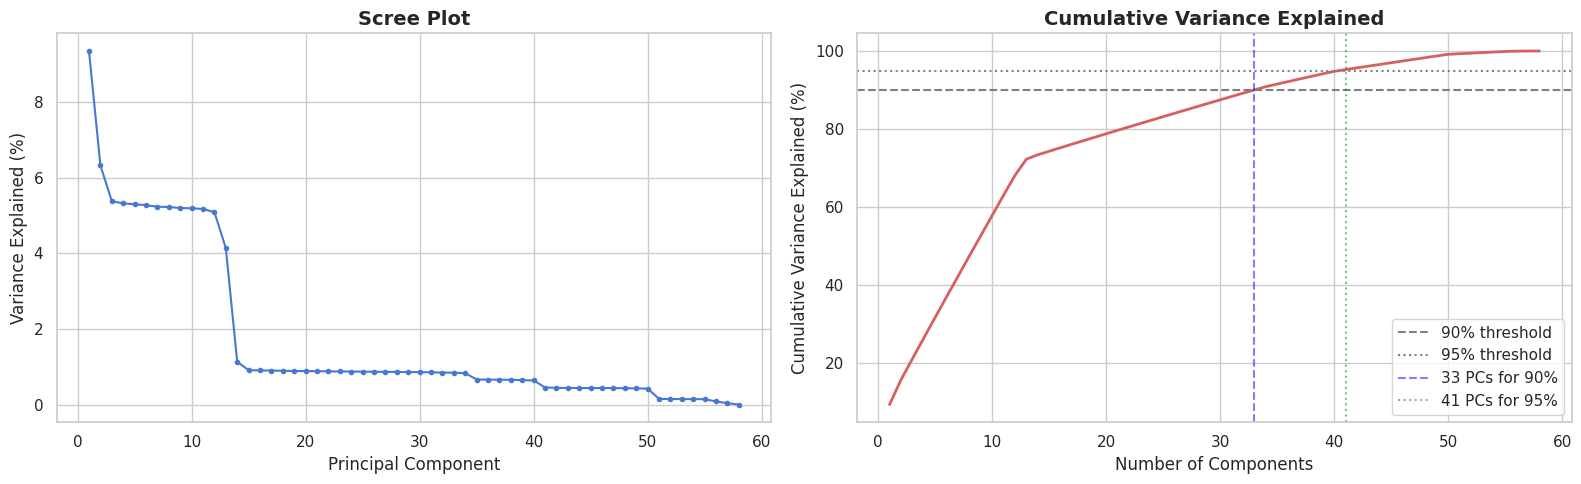

Components needed for 90% variance: 33
Components needed for 95% variance: 41
Total features: 58


In [23]:
from sklearn.decomposition import PCA

# Fit PCA on all features
pca_full = PCA(random_state=42)
pca_full.fit(X_train)

# Cumulative variance explained
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scree plot
axes[0].plot(range(1, len(pca_full.explained_variance_ratio_)+1), 
             pca_full.explained_variance_ratio_ * 100, 'bo-', markersize=3)
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Variance Explained (%)")
axes[0].set_title("Scree Plot", fontweight='bold')

# Cumulative variance
axes[1].plot(range(1, len(cumvar)+1), cumvar, 'r-', linewidth=2)
axes[1].axhline(y=90, color='gray', linestyle='--', label='90% threshold')
axes[1].axhline(y=95, color='gray', linestyle=':', label='95% threshold')
n_90 = np.argmax(cumvar >= 90) + 1
n_95 = np.argmax(cumvar >= 95) + 1
axes[1].axvline(x=n_90, color='blue', linestyle='--', alpha=0.5, label=f'{n_90} PCs for 90%')
axes[1].axvline(x=n_95, color='green', linestyle=':', alpha=0.5, label=f'{n_95} PCs for 95%')
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Variance Explained (%)")
axes[1].set_title("Cumulative Variance Explained", fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Components needed for 90% variance: {n_90}")
print(f"Components needed for 95% variance: {n_95}")
print(f"Total features: {X_train.shape[1]}")

**Observation on PCA:** Since most features are one-hot encoded (binary), variance is spread across many components. PCA doesn't provide a dramatic reduction. 

**Decision:** We will **not apply PCA** for the final model training and will instead use the full feature set. This preserves interpretability and allows feature importance analysis. However, the PCA analysis above is useful to understand the variance structure of our data.

## 18. Save Processed Data

We save the train/test splits and encoders so that teammates (Janessa, Su Ann, Hon Win, Sarah) can load them directly without repeating any preprocessing.

In [24]:
import joblib
import os

# Create output directory
os.makedirs("processed_data", exist_ok=True)

# Save train/test splits
X_train.to_csv("processed_data/X_train.csv", index=False)
X_test.to_csv("processed_data/X_test.csv", index=False)
y_train.to_csv("processed_data/y_train.csv", index=False)
y_test.to_csv("processed_data/y_test.csv", index=False)

# Save the scaler and target encoder for later use
joblib.dump(scaler, "processed_data/scaler.joblib")
joblib.dump(target_encoder, "processed_data/target_encoder.joblib")

# Save feature names
feature_names = X_train.columns.tolist()
pd.Series(feature_names).to_csv("processed_data/feature_names.csv", index=False, header=False)

print("✅ All processed data saved to 'processed_data/' folder:")
for f in sorted(os.listdir("processed_data")):
    size = os.path.getsize(f"processed_data/{f}")
    print(f"  📄 {f} ({size/1024:.0f} KB)")

print(f"\n--- Summary ---")
print(f"Training samples:  {X_train.shape[0]:,}")
print(f"Test samples:      {X_test.shape[0]:,}")
print(f"Features:          {X_train.shape[1]}")
print(f"Target classes:    {len(target_encoder.classes_)}")

✅ All processed data saved to 'processed_data/' folder:
  📄 X_test.csv (3554 KB)
  📄 X_train.csv (14216 KB)
  📄 feature_names.csv (1 KB)
  📄 scaler.joblib (1 KB)
  📄 target_encoder.joblib (1 KB)
  📄 y_test.csv (20 KB)
  📄 y_train.csv (78 KB)

--- Summary ---
Training samples:  40,000
Test samples:      10,000
Features:          58
Target classes:    10


In [25]:
# Quick verification — teammates can use this cell to load the data
print("=" * 60)
print("  FOR TEAMMATES: Copy this cell to load the processed data")
print("=" * 60)
print('''
import pandas as pd
import joblib

# Load train/test data
X_train = pd.read_csv("processed_data/X_train.csv")
X_test = pd.read_csv("processed_data/X_test.csv")
y_train = pd.read_csv("processed_data/y_train.csv").squeeze()
y_test = pd.read_csv("processed_data/y_test.csv").squeeze()

# Load encoders
scaler = joblib.load("processed_data/scaler.joblib")
target_encoder = joblib.load("processed_data/target_encoder.joblib")

print(f"Loaded: {X_train.shape[0]} train, {X_test.shape[0]} test, {X_train.shape[1]} features")
''')

  FOR TEAMMATES: Copy this cell to load the processed data

import pandas as pd
import joblib

# Load train/test data
X_train = pd.read_csv("processed_data/X_train.csv")
X_test = pd.read_csv("processed_data/X_test.csv")
y_train = pd.read_csv("processed_data/y_train.csv").squeeze()
y_test = pd.read_csv("processed_data/y_test.csv").squeeze()

# Load encoders
scaler = joblib.load("processed_data/scaler.joblib")
target_encoder = joblib.load("processed_data/target_encoder.joblib")

print(f"Loaded: {X_train.shape[0]} train, {X_test.shape[0]} test, {X_train.shape[1]} features")



## 19. Preprocessing Summary

| Step | Action | Details |
|------|--------|---------|
| **Missing Values** | No action needed | 0 missing values in all columns |
| **Dropped Columns** | Removed 3 | `app_usage_time_label`, `swipe_right_label`, `interest_tags` (redundant/high cardinality) |
| **Feature Engineered** | Added 1 | `num_interests` — count of interest tags per user |
| **Ordinal Encoding** | Applied to 2 | `income_bracket` (7 levels), `education_level` (9 levels) |
| **One-Hot Encoding** | Applied to 7 | `gender`, `sexual_orientation`, `location_type`, `swipe_time_of_day`, `zodiac_sign`, `body_type`, `relationship_intent` |
| **Target Encoding** | LabelEncoder | 10 match outcome classes → integers 0-9 |
| **Feature Scaling** | StandardScaler | Applied to all 15 numerical/ordinal features |
| **Train/Test Split** | 80/20 stratified | 40,000 train / 10,000 test |
| **PCA** | Explored, not applied | Full feature set retained for interpretability |

**The preprocessed data is saved in `processed_data/` and ready for model training.**

---
*Notebook prepared by Sri — Project Lead*  
*WIA1006/WID3006 Machine Learning, Sem 2, 2025/2026*